In [7]:
%matplotlib inline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs, load_iris, load_digits
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skimage import color, data as skdata
from skimage.transform import resize

<h1 style="font-size:42px;"> Spectral Clustering

# Abstract

Spectral clustering is a widely adopted clustering algorithm which involves graph theory, linear algebra and machine learning concepts. In this notebook, we will look into its mathemathical background, its definition, compare it with other clustering methods, make simple python implementations with a few imported modules and try it on real and artificial datasets and look at some of its applications.

# 1. Intorduction

## Why spectral clustering?

Well, I am a student in 10th grade who saw that linear algebra was pretty interesting and that it is not loooked into enough in school. My intention was to dive deeper into some of the more advanced topics in this field. But the idea for the project came from a classmate who has already finished the whole course 2 years ago. He heard I liked linear algebra and thought that would be a good idea. I was surprised by how easily methods for clustering could be used for identifying groups of similiar data samples and so I wanted to research more about it.

## Quick comparison with other clustering methods

| Feature                      | **k-means**                                       | **Spectral Clustering**                              |
|-----------------------------|---------------------------------------------------|------------------------------------------------------|
| **Assumes cluster shape** | Spherical, convex | Arbitrary (can be non-convex) |
| **Separability** | Linearly separable | Handles non-linear separability |
| **Distance metric** | Euclidean distance | Based on graph similarity |
| **Works on raw data?** | Yes | No - requires similarity matrix |
| **Computational cost** | Low (very fast) | Higher - requires eigen decomposition |
| **Handles complex shapes** | Poorly | Very well |
| **Number of clusters (k)** | Must be chosen in advance | Must be chosen in advance |
| **Interpretability** | High - uses centroids | Moderate - based on graph Laplacian eigenvectors |

# 2. Mathematical Background

## Graph theory concepts

* **Node** (also called a **vertex**): a fundamental element in a graph which represents **a point** or an entity
* **Edge**: a line which connects the different nodes in a graph; can be directed or undirected
<br>


![Example Graph](example_graph.png)
<br>

* **Adjacency matrix**: A square matrix where each element shows whether or not there's an edge between nodes i and j. If two of the nodes are adjacent, then the corresponding value in the matrix will be the weight of the edge (if we are talking about an unweighted graph, then the value in the matrix will just be one). Else, it will be zero. Here is the adjacency matrix of the example graph above (an unweighted undirected graph):

$$
A = \begin{bmatrix}
0 & 1 & 0 & 0 & 1 & 0 \\
1 & 0 & 1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 & 1 & 1 \\
1 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0
\end{bmatrix}
$$

In the general case, the adjacency matrix A is defined as:

$$
A \in \mathbb{R}^{n \times n}, \quad
A_{ij} = 
\begin{cases}
1\ \text{(or the weight of the edge\ } w_{ij}), & \text{if } (v_i, v_j) \in E \\
0, & \text{otherwise}
\end{cases}
$$

* **Degree matrix**: A matrix whose only elements which are not equal to zero are the ones on the main diagonal. Their values are the degrees of the nodes. The **degree of a vertix** is the number of the other vertices it is connected to. Here is the degree matrix of the example graph above:

$$
D = \begin{bmatrix}
2 & 0 & 0 & 0 & 0 & 0 \\
0 & 3 & 0 & 0 & 0 & 0 \\
0 & 0 & 2 & 0 & 0 & 0 \\
0 & 0 & 0 & 3 & 0 & 0 \\
0 & 0 & 0 & 0 & 3 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

In the general case, the degree matrix D is defined as:

$$
D \in \mathbb{R}^{n \times n}, \quad
D_{ij} = 
\begin{cases}
\deg(v_i), & \text{if } i = j \\
0, & \text{otherwise}
\end{cases}
$$

## Laplacian matrices

* **Unnormalized Laplacian matrix**: Easier to understand than the normalized Laplacian matrix. It has a lot of important properties such as:
    * can be used to calculate **the number of spanning trees** for a given graph
    * the first eigenvalue of the matrix is always 0. That means its corresponding eigenvector is the constant one vector.
    * the matrix has n non-negatiove, real-world eigenvalues:
    $$ 0 = \lambda_1 \le \lambda_2 \le \lambda_3 \le \dots \le \lambda_n$$
    * the **finest cut** of a graph can be approximated through the **Fiedler vector** — the eigenvector corresponding to the **second smallest eigenvalue** of the graph Laplacian. If the matrix is **symmetric**, the second lowest eigenvalue could be estimated this way:
    $$ \lambda_2 = \min_{x} \frac{x^TLx}{x^Tx}$$

where L is the unnormalized Laplacian matrix, defined as:

$$ L = D - A $$

So the example graph's unnormalized Laplacian looks like this:

$$
L = \begin{bmatrix}
2 & 0 & 0 & 0 & 0 & 0 \\
0 & 3 & 0 & 0 & 0 & 0 \\
0 & 0 & 2 & 0 & 0 & 0 \\
0 & 0 & 0 & 3 & 0 & 0 \\
0 & 0 & 0 & 0 & 3 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix} - 
\begin{bmatrix}
0 & 1 & 0 & 0 & 1 & 0 \\
1 & 0 & 1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 & 1 & 1 \\
1 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0
\end{bmatrix}
$$

$$
L = \begin{bmatrix}
2 & -1 & 0 & 0 & -1 & 0 \\
-1 & 3 & -1 & 0 & -1 & 0 \\
0 & -1 & 2 & -1 & 0 & 0 \\
0 & 0 & -1 & 3 & -1 & -1 \\
-1 & -1 & 0 & -1 & 3 & 0 \\
0 & 0 & 0 & -1 & 0 & 1
\end{bmatrix}
$$

*_BUT_: the unnormalized Laplacian matrix is not as used as the normalized, because the graph ought to be stable and balanced.

* **Normalized Laplacian matrix**: Its properties aren't so different from the **unnormalized Laplacian**. But it is more used in **spectral clustering** because it handles **irregular (unbalanced) graphs** better.

It is detonoted as L_sym beacause the matrix is symmetric and is defined as:

$$ L_{sym} = D^{-\frac{1}{2}} L D^{-\frac{1}{2}} = I - D^{-\frac{1}{2}} A D^{-\frac{1}{2} }$$

It will be hard to get to the solution for our example here so we will just leave like that.

* **Random walk Laplacian matrix**: There is also the random walk Laplacian, which is almost the same as a **normalized Laplacian**. It is called like that because it is closely related to a random walk. It is defined as:
$$ L_{rw} = D^{-1}L = I - D^{-1}A$$
Some of the properties of these 2 matrices are the same as those of the unnormalized Laplacian. However, they have some other important properties, such as:
    * Some eigenvalue of a normalized Laplacian is an eigenvalue of random walk Laplacian too only if it its corresponding eigenvector is:
    $$ \omega = D^{1/2}u$$
    * λ is an eigenvalue of Lrw with eigenvector u if and only if λ and u solve the generalized eigenproblem:
    $$ Lu = \lambda Du$$
    * Other properties

## What is clustering?

Clustering is an **unsupervised machine learning technique** applied in order to group **unlabeled** examples based on how similar they are to each other. This means that we, developers, are not involved in the learning process of our program. It is widely used to find relationships and patterns in the data. There are a lot of methods used for identifying well shaped clusters. We will look into some of them and even give examples with code.

## Clustering Algorithms

Now, let us get familiar with two very popular and easy to understand clustering algorithms. This will be helpful when we get to spectral clustering. They may not be as efficent as spectral clsutering, but they are worth getting looked into.

The two algorithms we are going to explain now are:

* **k-means clustering**: This clustering algorithm is probably the most popular one. It is not hard to understand. Fistly, we choose **how many clusters** we want to divide the graph into. This number is anotated as **k**. We choose **k random points** on the graph. These will be our **initial clusters**. Each point on the graph is then allocated to **the nearest initial cluster**. Ususally the nearest one is the one with the least **Euclidian distance** to the point. As a result of all of this, we get k clusters from the graph. The results may not appear ideal after the first try. To get better identified clusters, we have to apply the algorithm **multiple times**. This does not guarantee the best results, too. But we will definetely get well shaped clusters.
* **Hierarchial clustering**: To apply this algorithm, we first choose one point from the data and compare it to the **most "similar" to it** one. These 2 points then form a cluster. After that, the cluster is then compared to the other points in the dataset as a single point. This is repeated until all the points have been clustered. This method may be easy to understand, but provides mostly **untruthful results** (compared to other popular clustering algorithms).

## Spectral Clustering

The spectral clustering algorithm make use of the **eigenvalues of the similarity matrix** of the data to perform a **dimension reduction** and make the clustering in fewer diemnsions (as PCA does). **The similarity matrix is the input** and it represents the relative similarity of each pair of points in the dataset.

There are a few steps that are required for this type of clustering algorithm to work. There are **3 main algortihms** for spectral clustering: **Unnnormalized spectral clustering**, **Shi and Malik's algorithm** and **Ng-Jordan-Weiss Algorithm (Normalized Spectral Clustering)**. We will look into the 3rd algorithm more in detail. It was created in 2002 by Andrew Y. Ng, Michael I. Jordan and Yair Weiss and is one of the most widely adopted approaches. The **Normalized Spectral Clustering algorithm** is broken down into a few steps:

* Constructing the **similarity graph** - It is constructed from the similarity matrix given from the input. The creating such a graph can be performed in a few ways:
  
  * The **ε-neighborhood graph**: We connect all pairs of points whose distances between each other are **smaller than epsilon**. Epsilon is normally chosen in advance and the choice for its value is up to you. Graphs like these are usually considered to be **unweighted**.
  * **k-nearest neighbours graphs**: Here we connect 2 nodes if one of them is amongst the k (number of neighbors) nearest neighbors. There a 2 types of **undirected** k-nearest neighbours graphs. The first is a **k-nearest neighbor graph** where we just simply ignore the direction when connecting the vertices. The second one is called **mutual k-nearest neighbor graph** where both nodes are among each other's k nearest neighboors. This method of constructiong a similarity graph is one of the most widely used.
  * **The fully connected graph (adjacency matrix)**: We have already exlpained how to make these.
    <br>
    <br>
* Computing the **degree matrix D**

* Compute **Normalized Laplacian**:
  $$ L_{sym} = I - D^{-1/2}AD^{-1/2}$$
  
* **Eigen Decomposition**:
  * Compute the first k eigenvectors of the noramlized Laplacian
  * Stack them in a matrix:
    $$ U \in R^{n \times k}$$

* **Row-normalize** U to form matrix T: Each row of the matrix T has **unit length**. Mathematically, it looks like this:
  $$ T_i = \frac{U_i}{\Vert U_i \Vert}$$
  where i is the number of the row ∥⋅∥ is the **Euclidian norm**

* Apply **k-means** to the rows of T to get clusters


**Result**: $$ \text{Clusters } A_1, A_2, \dots, A_k$$

# 3. Python Implementation

Now we will see a simple python implementation of spectral clustering and k-means. We will use the **sklearn** module for the clustering and dataset generation and the **matplotlib** module for the visualizations. The input data for the functions will either be real or artificial. The functions can be tested with different parameters, even though you have to be careful wiht them. We will compare the results of both algorithms at the end and make our conclusions.

First, let us define the function which we will use for plotting the clusters. It will be called whenever we call one of the clustering methods we will implement below. The different clusters will have different colours. PCA will also be applied for data that has more than 2 dimensions. This will be needed in later examples:

In [48]:
def plot_clusters(X, labels, title="Cluster Plot"):
    """
    1. Description of parameters:
    X: the data which we want to plot
    labels: cluster labels
    title: title of the plot

    2. Explanation of code: We start by applying PCA to the data (if required). Then, we do the plotting.
    """
    
    # Reducing dimensions if necessary
    if X.shape[1] > 2:
        X_plot = PCA(n_components=2).fit_transform(X)
    elif X.shape[1] == 2:
        X_plot = X
    else:
        return

    # Plotting
    plt.figure(figsize=(6, 5))
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=labels, cmap='tab10', s=30)
    plt.title(title)
    plt.grid(True)
    plt.show()

Now, we can implement the two clustering methods. We will start with the **k-means** algorithm function:

In [49]:
def kmeans_clustering(X=None, y_true=None, data_type="moons", n_samples=300, noise=0.05, n_clusters=2, random_state=4):
    """
    1. Description of parameters:
    X - the dataset; can be provided or not
    y_true - tells us which cluster each point SHOULD belong to if it is known; used for clustering quality check
    data_type - provided only when working with artificial datasets; the options for it are: 'moons', 'circles', 'blobs'
    n_samples - how many points there are in the dataset when talking about artificial datasets; 300 by default
    noise - tells us what part of the dataset has points placed far away from any place with a lot of points close to each other; a big problem for k-means
    n_clusters - the number of clusters we want to identify
    random_state - controls the random number generator that shuffles the data before splitting it; used in machine learning for reproducing the same result

    2. Explanation of code: Firstly, we check to see if a dataset is provided. If not, then we check what data type is provided and initialize it. After that, 
    the data is standardized (making data comparable in scale to data with different scale). Then we apply k-means to the data, label the clusters and plot the
    results.
    """

    # Generating artificial dataset (if none is provided)
    if X is None:
        if data_type == "moons":
            X, y_true = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
        elif data_type == "circles":
            X, y_true = make_circles(n_samples=n_samples, noise=noise, factor=0.5, random_state=random_state)
        elif data_type == "blobs":
            X, y_true = make_blobs(n_samples=n_samples, centers=n_clusters, random_state=random_state)
        else:
            raise ValueError("Invalid data type!")

    # Standardizing the data
    X = StandardScaler().fit_transform(X)

    # Applying k-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    labels = kmeans.fit_predict(X)

    # Plotting
    plot_clusters(X, labels, title=f"K-Means Clustering ({data_type}, clusters={n_clusters})")

    return X, labels, y_true

After that, we will define the **spectral clustering** algorithm function:

In [1]:
def spectral_clustering(
    X=None,
    y_true=None,
    data_type="moons",
    n_samples=300,
    noise=0.05,
    n_clusters=2,
    affinity="rbf",
    gamma=15.0,
    n_neighbors=10,
    random_state=4,
):
    """
    1. Description of parameters which aren't in the k-means algorithm function:
    affinity - tells us what type of similarity matrix to construct; can be either 'rbf' (Gaussian kernel) or 'nearest neighboors' (k-nearest neighboors)
    gamma - used when our choice for the similarity matrix is to be constructed using the Gaussian kernel
    n_neighboors - used when our choice for the similarity matrix is to be constructed using the k-nearest neighboors

    2. Explanation of code: The first few steps are the same as k-means. After that, we construct the similarity matrix in the way that is provided to us. We
    apply spectral clustering and plot the reuslts.
    """

    # Generating artificial dataset (if none is provided)
    if X is None:
        if data_type == "moons":
            X, y_true = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
        elif data_type == "circles":
            X, y_true = make_circles(n_samples=n_samples, noise=noise, factor=0.5, random_state=random_state)
        elif data_type == "blobs":
            X, y_true = make_blobs(n_samples=n_samples, centers=n_clusters, random_state=random_state)
        else:
            raise ValueError("Invalid data type. Choose 'moons', 'circles', or 'blobs'.")

    # Standardizing the data
    X = StandardScaler().fit_transform(X)

    # Constructing the similarity matrix and applying spectral clustering
    if affinity == "rbf":
        similarity_matrix = rbf_kernel(X, gamma=gamma)
        clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='kmeans', random_state=random_state)
        labels = clustering.fit_predict(similarity_matrix)
    elif affinity == "nearest_neighbors":
        clustering = SpectralClustering(
                                        n_clusters=n_clusters, 
                                        affinity='nearest_neighbors', 
                                        n_neighbors=n_neighbors, 
                                        assign_labels='kmeans', 
                                        random_state=random_state
                                       )
        labels = clustering.fit_predict(X)
    elif affinity == "precomputed":
        clustering = SpectralClustering(
            n_clusters=n_clusters,
            affinity='precomputed',
            assign_labels='kmeans',
            random_state=random_state
        )
        labels = clustering.fit_predict(X)
    else:
        raise ValueError("Affinity must be 'rbf', 'nearest_neighbors' or 'precomputed'")

    # Plotting
    plot_clusters(X, labels, title=f"Spectral Clustering (clusters={n_clusters}, affinity='{affinity}')")

    return X, labels, y_true

As we can see, both functions have a lot of parameters, most of which are optional and have default values. The functions are pretty similar to each other and easy to understand because the sklearn module makes our lives a lot easier.

Now, we will see how the two clustering algorithms compare with linearly and non-linearly seperable clusters and real dartasets. We will also evaluate their performances using the clustering metric **Adjusted Rand Index (ARI)** using the corresponding function from the sklearn module.

First, let us start with the artifiacial datasets. The first is the **moons** dataset:

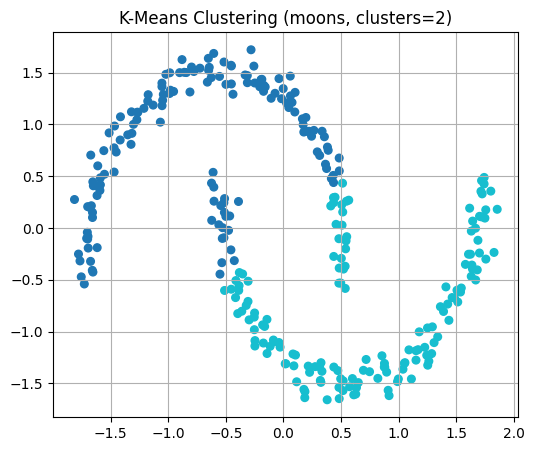

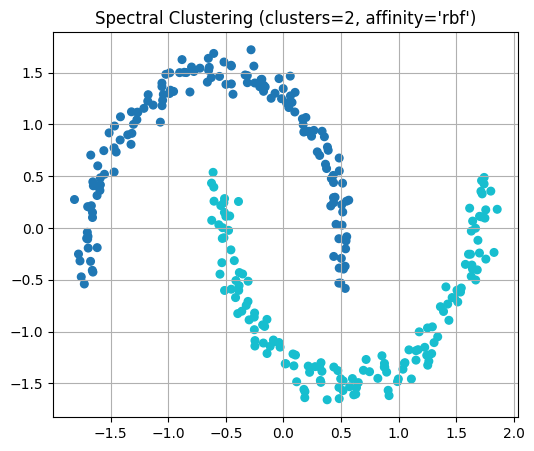

K-Means' ARI: 0.49769813709283395
Spectral clustering's ARI: 1.0


In [23]:
X, kmeans_labels, y_true = kmeans_clustering(data_type="moons", n_clusters=2)
_, spectral_labels, _ = spectral_clustering(X=X, y_true=y_true, data_type="moons", n_clusters=2, affinity="rbf", gamma=15)

# Evaluating clustering quality
print(f"K-Means' ARI: {adjusted_rand_score(y_true, kmeans_labels)}")
print(f"Spectral clustering's ARI: {adjusted_rand_score(y_true, spectral_labels)}")

Here, we can see how applying spectral clustering gets us a perfect ARI score and that k-means fails to identify good clusters when we have a dataset that can't be seperated into well-defined groups with just one straight line.

Let us see another comparison, this time with **circles** which is non-linearly seperable, too:

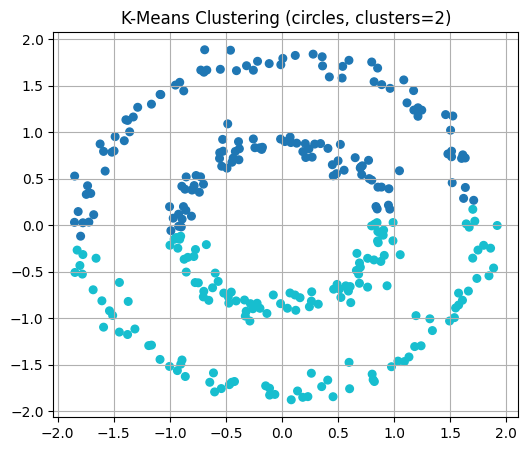

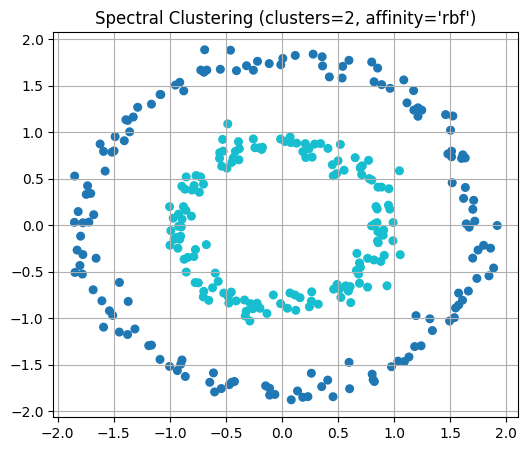

K-Means' ARI: -0.003309764386595156
Spectral clustering's ARI: 1.0


In [24]:
X, kmeans_labels, y_true = kmeans_clustering(data_type="circles", n_clusters=2)
_, spectral_labels, _ = spectral_clustering(X=X, y_true=y_true, data_type="circles", n_clusters=2, affinity="rbf", gamma=15)

print(f"K-Means' ARI: {adjusted_rand_score(y_true, kmeans_labels)}")
print(f"Spectral clustering's ARI: {adjusted_rand_score(y_true, spectral_labels)}")

We can yet again confirm our intitial views form the first example - spectral clustering is really powerful when it comes to with non-linearly seperable clusters and k-means clustering isn't.

Now that we have seen both algorithms' performances on these types of clusters, let us see what they do with linearly seperable clusters. We can try them on a **blob** dataset:

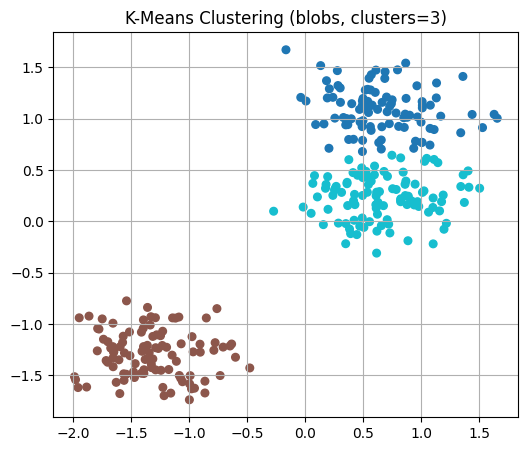

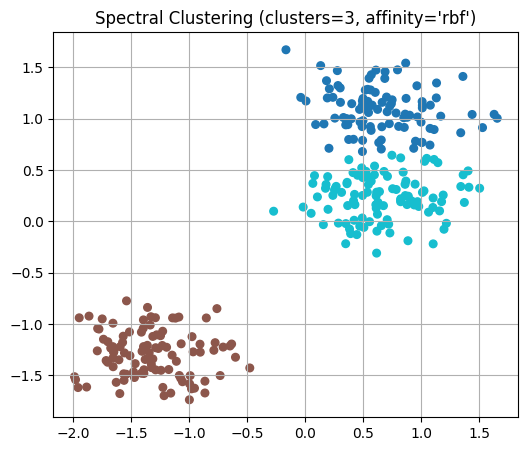

K-Means' ARI: 0.9227038569978269
Spectral clustering's ARI: 0.9227038569978269


In [25]:
X, kmeans_labels, y_true = kmeans_clustering(data_type="blobs", n_clusters=3)
_, spectral_labels, _ = spectral_clustering(X=X, y_true=y_true, data_type="blobs", n_clusters=3, affinity="rbf", gamma=15)

print(f"K-Means' ARI: {adjusted_rand_score(y_true, kmeans_labels)}")
print(f"Spectral clustering's ARI: {adjusted_rand_score(y_true, spectral_labels)}")

Now we see where the two clustering methods provide equal results. Even though they don't have a prefecr ARI score, they still identified some pretty well-defined clusters. From this, we can make the conlcusion that k-means comes close to more powerful clustering algorithms when we are talking about linearly seperable clusters.

Finally, we can try testing them on a **real dataset**. To do that, we will need to load the dataset. This can be done by importing **Iris** from the sklearn module and then **standardizing it**:

In [37]:
test_data = load_iris()
X = StandardScaler().fit_transform(test_data.data)
y_true = test_data.target

Now let us test it:

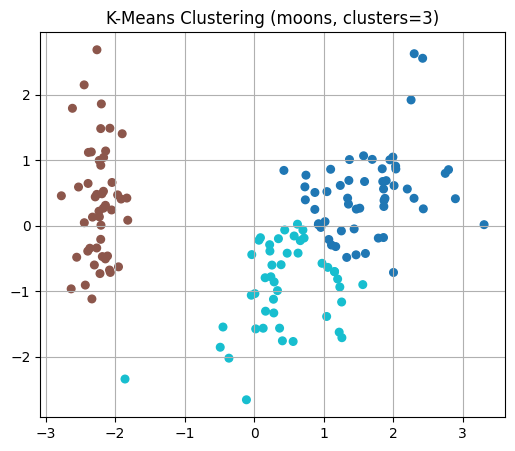

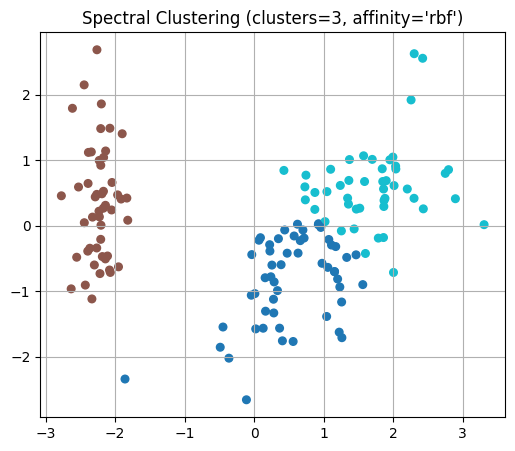

K-Means' ARI: 0.645147003482001
Spectral clustering's ARI: 0.5995816019019579


In [38]:
X, kmeans_labels, _ = kmeans_clustering(X=X, y_true=y_true, n_clusters=3)
_, spectral_labels, _ = spectral_clustering(X=X, y_true=y_true, n_clusters=3, affinity='rbf', gamma=0.5)

print(f"K-Means' ARI: {adjusted_rand_score(y_true, kmeans_labels)}")
print(f"Spectral clustering's ARI: {adjusted_rand_score(y_true, spectral_labels)}")

But what do we see here - in this case, k-means performs slightly better than spectral clustering in this case. Even when we change the number of clusters (which is not good practice in this case), the result still shows k-means' advantage. That may be because it looks like there are linearly seperable clusters.

**In conlusion**: Spectral clustering works well in almost all types of datasets and k-means works well mostly only when it comes to linearly seperable clusters.

Now, you can try it yourself. You can play a bit with the paramters, try the two algorithms in different situations and do your own comaprisons:

In [34]:
# write your your own examples here

# 4. Applications

Now, we will look at some of the appllications of spectral clustering and show examples with code of some of them. It can be used in some very interesting fields. 

## Image Segmentation

Using spectral clustering, we can **divide the image into clusters of similar colour (or texture)**. To make our example program work less hard, we should convert the images to greyscale (black and white):

In [58]:
def image_segmentation(image=None, image_name='astronaut', image_size=(64, 64), 
                           n_clusters=4, gamma=25):
    """
    1. Description of parameters:
        image : optional; a custom image as a numpy array
        image_name: if no image is provided, a predefined image is loaded; could be 'astronaut', 'camera', 'coins' or others
        image_size: the resized image dimensions (height, width)
        n_clusters: number of clusters we want to divide the image into
        gamma: gamma parameter for the RBF kernel

    2. Explanation of code: First, we load the image if none is provided. Then, we convert it to greyscale if needed. After that spectral clustering is applied
    and the image is rebuilt using the newly created clusters (like a puzzle). Finally, we plot the results (because the spectral clusteing function only plots
    data with 2 or more dimensions).
    """
    
    # Loading from skimage (if no image is provided)
    if image is None:
        if hasattr(skdata, image_name):
            image = getattr(skdata, image_name)()
        else:
            raise ValueError(f"Invalid image name '{image_name}'. Try 'astronaut', 'camera', 'coins', etc.")

    # Converting to grayscale (if needed) and resizing
    if image.ndim == 3:  # RGB
        image = color.rgb2gray(image)
    image = resize(image, image_size, anti_aliasing=True)
    X_img = image.reshape(-1, 1)

    # Applying spectral clustering
    X_clustered, labels, _ = spectral_clustering(X=X_img, n_clusters=n_clusters, affinity='rbf', gamma=gamma)

    # Reshaping labels to image
    segmented = labels.reshape(image.shape)

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image, cmap='gray')

    plt.subplot(1, 2, 2)
    plt.title("Segmented Image")
    plt.imshow(segmented, cmap='viridis')
    plt.show()

Now let us try a few examples with images from the skimage module:

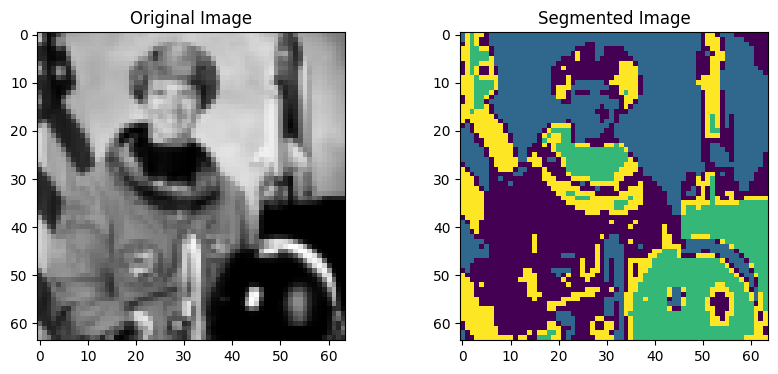

In [63]:
image_segmentation(
    image=None,
    image_name='astronaut',
    image_size=(64, 64),
    n_clusters=4,
    gamma=25
)

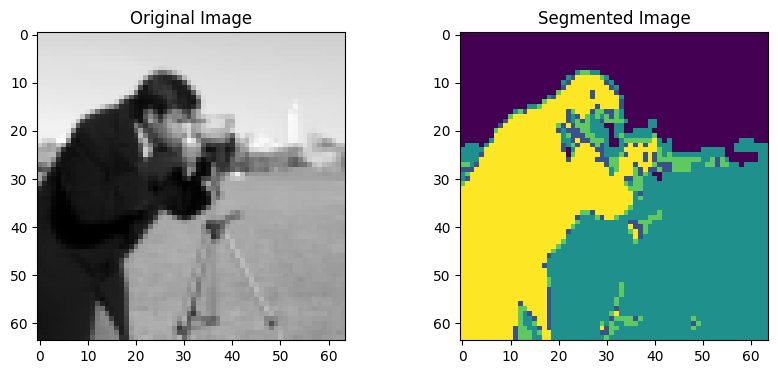

In [62]:
image_segmentation(
    image=None,
    image_name='camera',
    image_size=(64, 64),
    n_clusters=5,
    gamma=30
)

And now, let us try with a numpy array. To do that, we will first need to define it:

In [65]:
# defining the array
custom_image = np.zeros((64, 64))
custom_image[:, :32] = 0.2   # making the left half dark red
custom_image[:, 32:] = 0.8   # making the right half light gray

We can now try it:

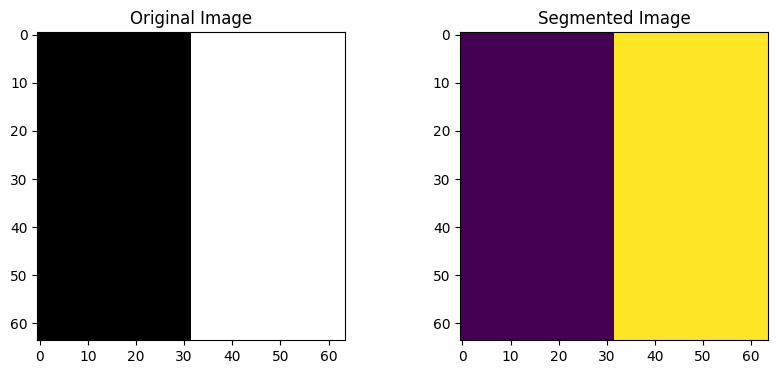

In [66]:
run_image_segmentation(
    image=custom_image,     # passing our custom image directly
    image_size=(64, 64),    # this size matches already, so resizing is trivial
    n_clusters=2,
    gamma=20
)

An interesting observation we can make here is that the clusters (regions with the same colour) are not close to each other in a few places. We have already said that the clusters identified by the tone of the colours of the different pixels (the similarity factor is the Gaussian kernel).

## GPS coordinates (clustering cities)

Using spectral clustering, we can **divide the world into regions with big cities close to each other**. Now, we will see a simple example of this:

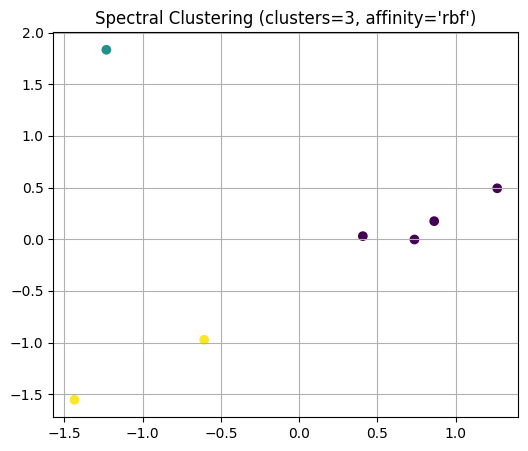

In [12]:
X_cities = np.array([
    [48.8566, 2.3522],    # Paris
    [51.5074, -0.1278],   # London
    [40.7128, -74.0060],  # New York
    [34.0522, -118.2437], # Los Angeles
    [35.6895, 139.6917],  # Tokyo
    [55.7558, 37.6173],   # Moscow
    [52.5200, 13.4050]    # Berlin
])

_, _, _ = spectral_clustering(X=X_cities, n_clusters=3)

It may be difficult to see, but these points are meant to represent the cities' coordinates on the world map. As we can see, the cities who are closer to each other are in a cluster and the ones further away - in other clusters.

## Other Interesting Applications

### Social Networking Clustering

We can **identify communities** in a social networking graph using spectral clustering. This can be done by clustering **the whole graph** or by clustering **a part of it (a subgraph)** with a simple list of nodes. We will try examples with both. But let us implement the function first:

### Clustering Digits from MNIST

Spectral clustering can also be used when clustering digits from **the MNIST database (a large database of handwritten digits)**.

### Gene Expression Data Clustering

We can **group genes/samples with similar expression patterns**.

# 5. Conclusion

## Summarizing my work and what I leaned

I had to learn a lot of things before starting the project. I started with linear algebra and a little deeper than needed, because it seemed interesting. Then, learned the basics of graph theory in order to learn how to create adjacency, degree and Laplacian matrices. After that, I learned about k-means clustering and hierarchial clustering. I did this so I could have a better foundation about more complex clustering algortihms. Then, I used my knowledge of linear algebra paired with graph theory to start working on my main goal - learning spectral clustering and making a project about it. But before that, I went through PCA and k-nearest neighboors for better understanding of clustering. It was hard finding a good place to learn spectral clustering, but eventually I found reliable sources. 

But I still had to look for code examples, implementations, libraries and such. So I learned make simple implementations of k-means and spectral clustering using the scikit-learn module. It had a lot of built-in functions and was way easier to implement than doing it manually with numpy.

I started by first choosing the structure of the notebook. I got a little help from a certain chat bot. Then, I started by explaining a few key graph theory concepts and linear algebra related topics. Then, I explained what clustering is and some of the most popular methods for performing it. What followed was description of spectral clustering and how to apply it. Then came the implementation part. I started by firstly defining the k-means function and then the spectral clustering one. I used a bit of help ot make the functions interacive (even though it may have not been a good idea). After that, I did a bit of tests and made conclusions. I decided to put a field for the readers to make some example inputs if they wanted to. 

Then, I decided to get familiar with some of the applications of spectral clustering. I also wanted to show some of them with simple in action with simple implementations. I did not expect this to be the hardest part. I wanteed to add image segmentation and thought it would not be that hard. I was proven wrong after a lot of trying to get the code to work. That is why I had to ask the same chat bot for a bit of help. I eventually got it to wrok. But in order to that, I had to make the plotting function for both the clustering functions a seperate function and apply PCA to any data with more than 2 dimensions. I had to do that beacause the image is has 3 dimensions and I can only plot data with 2 dimensions. After that, I made simple implementation of cities'coordinates. I also wanted to do social networking clustering. I had to use the networkx module in order to do that. But I had a lot of problems with it and decided to just leave it like that.

That was the whole my whole work. I leaned a lot of tings along the way - linear algebra, graph theory basics, clsutering and spectral clustering. It took me around one week to learn these things and 10 hours to finish the project.

## Strengths and Weaknesses of Spectral Clustering

Spectral clustering is one of the most widely used clustering algorithms out there. It has a lot of stringths, but it also has its weaknesses. Now we will make a summary of most of them:

| **Aspect**                   | **Strengths**                                                                 | **Weaknesses**                               |
|-----------------------------|-------------------------------------------------------------------------------|-----------------------------------------------|
| **Non-linearity** | Can detect complex, non-convex cluster shapes (moons, circles and other) | May fail if the similarity graph is not well constructed|
| **Flexibility in affinity** | Uses different ways for constructing the similarity matrix (RBF, nearest neighbors and other) | Performance heavily depends on the choice of similarity function and parameters |
| **Shape** | Does not assume clusters are spherical or equally sized | The following use of k-means can still cause problems|
| **Dimensionality** | Can work in high-dimensional space using eigen-decomposition | Eigen-decomposition is computationally costly and less scalable|
| **Intuitive for networks**  | Really efficient for clustering graphs and social networks | It is not always easy to interpret the resulting clusters|

## Future development

As I have already said, I am pretty interested in linear algebra. There are a lot of topics I can study and get deeper into. It is probably safe to say I am not going to run out of ideas.

# 6. References

* [Graph theory - Wikipidea](https://en.wikipedia.org/wiki/Graph_theory): for graph theory basics
* [Shri Ram Programming Academy](https://www.youtube.com/@rambhaktsharma/videos): youtube channel, which helped for visually understanding adjacency, degree and unnormalized Laplacian matrices
* [StatQuest with Josh Starmer](https://www.youtube.com/@statquest): youtube channel, which helped with understanding PCA, hierarchial clustering, k-means clustering, k-nearest neighboors and clustering as a whole both theoretically and visually
* [A Tutorial on Spectral Clustering](https://people.csail.mit.edu/dsontag/courses/ml14/notes/Luxburg07_tutorial_spectral_clustering.pdf): for normalized Laplacian and some of its properties and for spectral clustering; also, what the preconditions for spectral clustering were
* [Spectral clustering - Wikipedia](https://en.wikipedia.org/wiki/Spectral_clustering): helped with some of the definitions
* [Scikit-learn - KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): for python implementaion of k-means
* [Scikit-learn - SpectalClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html): for python implementation of spectral clustering
* [Chat GPT](https://chatgpt.com/?model=auto): helped a lot for the structure, the implementaions and the applications